<a href="https://colab.research.google.com/github/sababatamanna/ML/blob/main/Task2_AI_Tshape_PEH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SETUP**

In [ ]:
!pip install openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
import os
print(os.listdir())

['.config', 'T shape dataset.xlsx', 'sample_data']


**LOAD** **DATASET**

In [ ]:
df = pd.read_excel("T shape dataset.xlsx")
print(df.head())

   Max Width(x)  Max Depth(y)  Max Height(z)  Volumn(mm3)  Surface Area(mm2)  \
0          20.0           6.0            0.3         86.4              207.6   
1          20.5           6.0            0.3         86.7              209.9   
2          21.0           6.0            0.3         87.0              212.2   
3          21.5           6.0            0.3         87.3              214.5   
4          22.0           6.0            0.3         87.6              216.8   

  Mass Width  Mass Depth  Mass Height  Clamped width  Clamped Depth  \
0          2         6.0          6.0            2.0            6.0   
1          2         6.0          6.0            2.0            6.0   
2          2         6.0          6.0            2.0            6.0   
3          2         6.0          6.0            2.0            6.0   
4          2         6.0          6.0            2.0            6.0   

   Eigenfrequency  Voltage    Power Angular Frequency   Damping  \
0            59.0   4.773

In [ ]:
print(df.shape)

(329, 16)


**DATA INSPECTION**

Data Cleaning

In [ ]:
df = df.rename(
    columns=
    {
        "Volumn(mm3)": "  Volume(mm3)"
    }
)
print(df.columns)

Index(['Max Width(x)', 'Max Depth(y)', 'Max Height(z)', '  Volume(mm3)',
       'Surface Area(mm2)', 'Mass Width', 'Mass Depth', 'Mass Height',
       'Clamped width', 'Clamped Depth', 'Eigenfrequency', 'Voltage', 'Power',
       'Angular Frequency', 'Damping', 'Quality factor'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329 entries, 0 to 328
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Max Width(x)       324 non-null    float64
 1   Max Depth(y)       324 non-null    float64
 2   Max Height(z)      324 non-null    float64
 3     Volume(mm3)      324 non-null    float64
 4   Surface Area(mm2)  324 non-null    float64
 5   Mass Width         326 non-null    object 
 6   Mass Depth         324 non-null    float64
 7   Mass Height        324 non-null    float64
 8   Clamped width      324 non-null    float64
 9   Clamped Depth      324 non-null    float64
 10  Eigenfrequency     324 non-null    float64
 11  Voltage            321 non-null    float64
 12  Power              321 non-null    float64
 13  Angular Frequency  324 non-null    object 
 14  Damping            324 non-null    float64
 15  Quality factor     324 non-null    float64
dtypes: float64(14), object(2)


In [ ]:
missing = df.isnull().sum()
print(missing)

Max Width(x)         5
Max Depth(y)         5
Max Height(z)        5
  Volume(mm3)        5
Surface Area(mm2)    5
Mass Width           3
Mass Depth           5
Mass Height          5
Clamped width        5
Clamped Depth        5
Eigenfrequency       5
Voltage              8
Power                8
Angular Frequency    5
Damping              5
Quality factor       5
dtype: int64


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 84


In [ ]:
df.describe()

,Max Width(x),Max Depth(y),Max Height(z),Volume(mm3),Surface Area(mm2),Mass Depth,Mass Height,Clamped width,Clamped Depth,Eigenfrequency,Voltage,Power,Damping,Quality factor
count,324.000000,324.000000,3.240000e+02,324.000000,324.000000,324.0,324.0,324.000000,324.000000,324.000000,321.000000,321.000000,324.000000,324.000000
mean,21.470679,7.305556,3.000000e-01,146.212068,257.105247,6.0,6.0,2.975309,7.305556,43.729321,18.831852,9368.036639,0.001002,511.920957
std,2.448207,0.864236,1.723507e-15,38.760436,24.285934,0.0,0.0,0.905440,0.864236,11.097590,5.194121,4922.690530,0.000168,80.169331
min,15.000000,6.000000,3.000000e-01,83.400000,184.600000,6.0,6.0,2.000000,6.000000,27.200000,1.731300,16.598000,0.000703,298.090000
25%,20.000000,7.000000,3.000000e-01,117.525000,242.500000,6.0,6.0,2.000000,7.000000,36.600000,15.480000,5882.500000,0.000877,456.855000
50%,21.500000,7.500000,3.000000e-01,139.050000,257.850000,6.0,6.0,3.000000,7.500000,41.750000,18.541000,8555.400000,0.000979,510.555000
75%,23.500000,8.000000,3.000000e-01,176.255000,273.525000,6.0,6.0,3.500000,8.000000,47.725000,22.138000,12197.000000,0.001094,569.870000
max,25.000000,9.000000,3.000000e-01,232.500000,313.200000,6.0,6.0,5.000000,9.000000,91.100000,32.720000,25149.000000,0.001677,711.330000


In [ ]:
df.to_csv(
    "T_shape_cleaned.csv",
     index= False
)

Dataset contains 329 samples and 16 columns.
Column names were inspected and Volume(mm3) was standardized . Missing values checked.

In [ ]:
print(df["Mass Width"].unique())

[2 nan 'output parameters' 'Input parameters']


In [ ]:
df["Mass Width"] = pd.to_numeric(df["Mass Width"], errors="coerce")

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329 entries, 0 to 328
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Max Width(x)       329 non-null    float64
 1   Max Depth(y)       329 non-null    float64
 2   Max Height(z)      329 non-null    float64
 3     Volume(mm3)      329 non-null    float64
 4   Surface Area(mm2)  329 non-null    float64
 5   Mass Width         324 non-null    float64
 6   Mass Depth         329 non-null    float64
 7   Mass Height        329 non-null    float64
 8   Clamped width      329 non-null    float64
 9   Clamped Depth      329 non-null    float64
 10  Eigenfrequency     329 non-null    float64
 11  Voltage            329 non-null    float64
 12  Power              329 non-null    float64
 13  Angular Frequency  324 non-null    object 
 14  Damping            329 non-null    float64
 15  Quality factor     329 non-null    float64
dtypes: float64(15), object(1)


In [ ]:
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
print(df.isnull().sum())

Max Width(x)         0
Max Depth(y)         0
Max Height(z)        0
  Volume(mm3)        0
Surface Area(mm2)    0
Mass Width           0
Mass Depth           0
Mass Height          0
Clamped width        0
Clamped Depth        0
Eigenfrequency       0
Voltage              0
Power                0
Angular Frequency    5
Damping              0
Quality factor       0
dtype: int64


In [ ]:
input_features = [
    "Max Width(x)",
    "Max Depth(y)",
    "Max Height(z)",
    "  Volume(mm3)",
    "Surface Area(mm2)",
    "Mass Width",
    "Mass Depth",
    "Mass Height",
    "Clamped width",
    "Clamped Depth"
]

targets = [
    "Eigenfrequency",
    "Voltage",
    "Power",
    "Quality factor"
]

X = df[input_features]

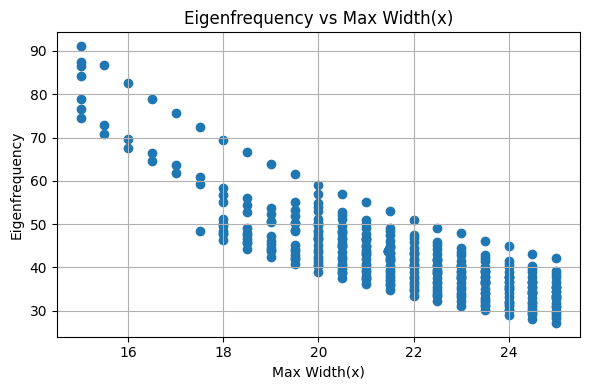

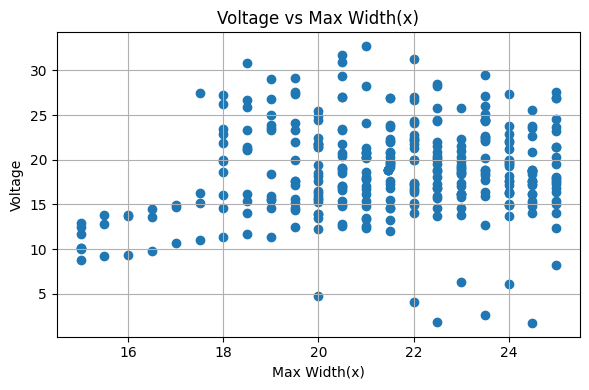

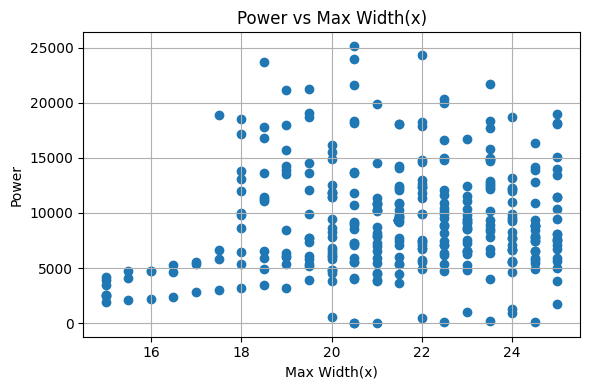

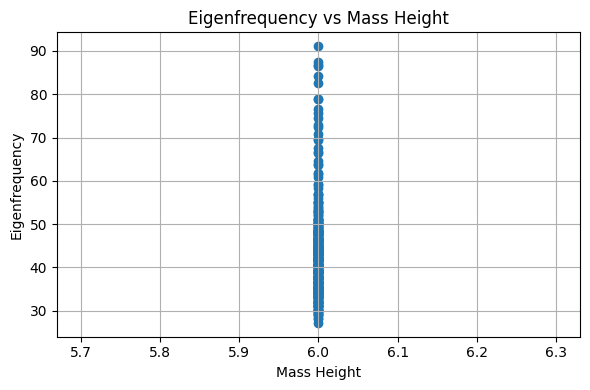

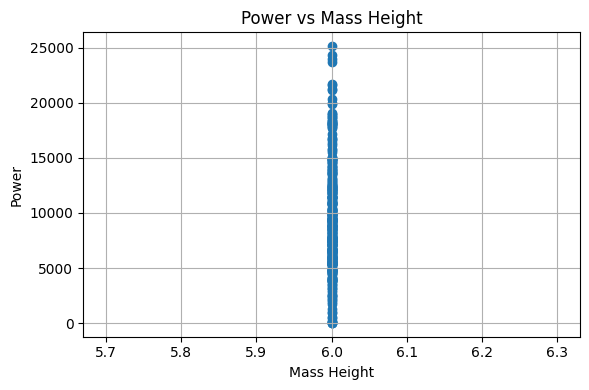

In [ ]:
import os
os.makedirs("plots", exist_ok=True)

plot_pairs = [
    ("Max Width(x)", "Eigenfrequency"),
    ("Max Width(x)", "Voltage"),
    ("Max Width(x)", "Power"),
    ("Mass Height", "Eigenfrequency"),
    ("Mass Height", "Power")
]

for x_col, y_col in plot_pairs:
    plt.figure(figsize=(6,4))
    plt.scatter(df[x_col], df[y_col])

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col}")

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        f"plots/{y_col}_vs_{x_col}.png"
        .replace(" ","_")
        .replace("/","_"),
        dpi=300
    )

    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

input_features = [
    "Max Width(x)",
    "Max Depth(y)",
    "Max Height(z)",
    "  Volume(mm3)",
    "Surface Area(mm2)",
    "Mass Width",
    "Mass Depth",
    "Mass Height",
    "Clamped width",
    "Clamped Depth"
]

X = df[input_features]

y = df["Eigenfrequency"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 263
Testing samples: 66


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "MLP Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64,32),
            activation="relu",
            max_iter=2000,
            random_state=42
        ))
    ])
}

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2, y_pred

In [ ]:
targets = [
    "Eigenfrequency",
    "Voltage",
    "Power",
    "Quality factor"
]

all_results = []

for target in targets:

    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    for model_name, model in models.items():

        model.fit(X_train, y_train)

        mae, rmse, r2, y_pred = evaluate_model(
            model,
            X_test,
            y_test
        )

        all_results.append([
            target,
            model_name,
            mae,
            rmse,
            r2
        ])

results_df = pd.DataFrame(
    all_results,
    columns=["Target","Model","MAE","RMSE","R2"]
)

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


            Target              Model          MAE         RMSE        R2
0   Eigenfrequency  Linear Regression     2.038990     2.668157  0.930225
1   Eigenfrequency      Random Forest     0.625677     0.842923  0.993036
2   Eigenfrequency      MLP Regressor     0.357908     0.475765  0.997781
3          Voltage  Linear Regression     3.631927     4.621575  0.380390
4          Voltage      Random Forest     2.768447     3.694361  0.604071
5          Voltage      MLP Regressor     2.857883     3.837068  0.572892
6            Power  Linear Regression  3641.792827  4719.870469  0.152485
7            Power      Random Forest  2974.718687  4377.258671  0.271060
8            Power      MLP Regressor  3340.321950  4535.097270  0.217543
9   Quality factor  Linear Regression     4.874670     6.296971  0.994232
10  Quality factor      Random Forest     5.135087     6.719152  0.993432
11  Quality factor      MLP Regressor     3.725798     4.668000  0.996830


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
import os
os.makedirs("results", exist_ok=True)
results_df.to_csv(
    "results/model_results.csv",
    index=False
)

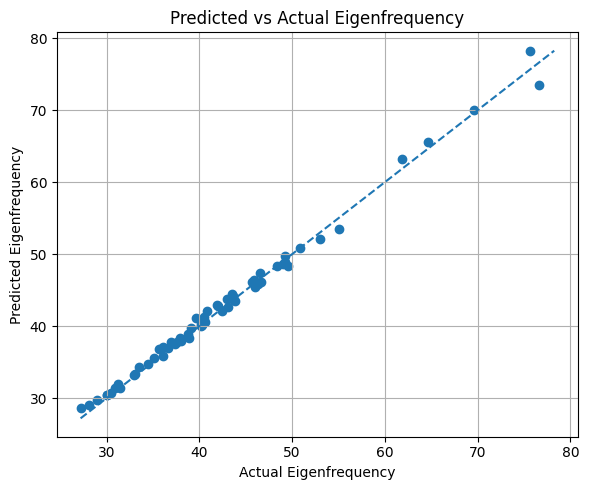

In [ ]:
y = df["Eigenfrequency"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Eigenfrequency")
plt.ylabel("Predicted Eigenfrequency")
plt.title("Predicted vs Actual Eigenfrequency")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val,max_val],
    [min_val,max_val],
    "--"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "plots/predicted_vs_actual_eigenfrequency.png",
    dpi=300
)

plt.show()

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": input_features,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

             Feature  Importance
0       Max Width(x)    0.681035
4  Surface Area(mm2)    0.218075
3        Volume(mm3)    0.083253
8      Clamped width    0.006443
1       Max Depth(y)    0.005794
9      Clamped Depth    0.005399
5         Mass Width    0.000000
2      Max Height(z)    0.000000
7        Mass Height    0.000000
6         Mass Depth    0.000000


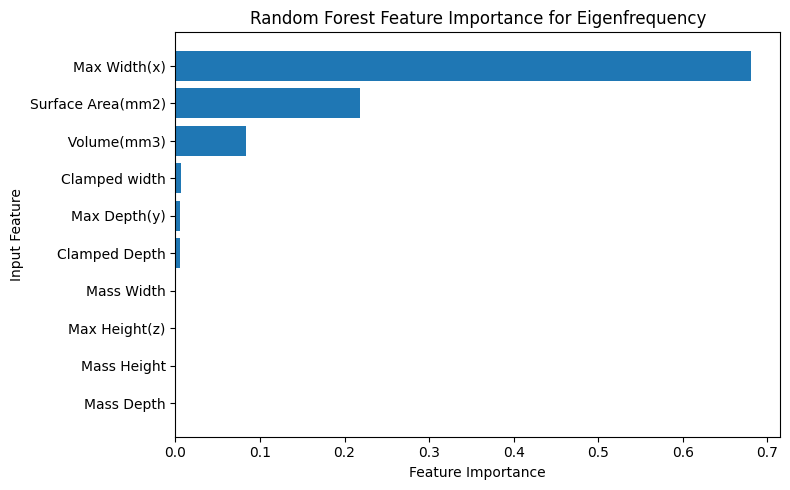

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Input Feature")

plt.title(
    "Random Forest Feature Importance for Eigenfrequency"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "plots/feature_importance_eigenfrequency.png",
    dpi=300
)

plt.show()

In [42]:
import os

os.makedirs("results", exist_ok=True)

df.to_csv(
    "results/T_shape_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
